In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt
from astropy.io import fits
from lmfit.model import load_modelresult


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()  # asumiendo que abres Jupyter en la raíz del repo

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, STRUCTURE_DIR, FIGS_DIR
import results_comp
import plot_fit_params
import ci_results_compiler
import bfunc

In [3]:
H_file_name  = "MUSE-M42-H-bin0"
H1_file_name = "MUSE-M42-H-bin1"
H2_file_name = "MUSE-M42-H-bin2"
H3_file_name = "MUSE-M42-H-bin3"
H4_file_name = "MUSE-M42-H-bin4"

labels = [
         'H0',
          'H1',
          'H2',
          'H3',
    'H4'
         ]

In [4]:
H_ = results_comp.load_line_bundle_mat(H_file_name, "H_line", MAPS_DIR, read_header=True)
H1_ = results_comp.load_line_bundle_mat(H1_file_name, "H1_line", MAPS_DIR, read_header=True)
H2_ = results_comp.load_line_bundle_mat(H2_file_name, "H2_line", MAPS_DIR, read_header=True)
H3_ = results_comp.load_line_bundle_mat(H3_file_name, "H3_line", MAPS_DIR, read_header=True)
H4_ = results_comp.load_line_bundle_mat(H4_file_name, "H4_line", MAPS_DIR, read_header=True)


obs = [
    H_['meta']['SIG2'], 
    H1_['meta']['SIG2'], 
    H2_['meta']['SIG2'],
    H3_['meta']['SIG2'],
    H4_['meta']['SIG2']
]


In [5]:
H_line = H_['fit'].to_dict(orient='list')
H1_line = H1_['fit'].to_dict(orient='list')
H2_line = H2_['fit'].to_dict(orient='list')
H3_line = H3_['fit'].to_dict(orient='list')
H4_line = H4_['fit'].to_dict(orient='list')


# Pdfs


In [6]:
H_mask = (H_['mask'] !=0)
H1_mask = (H1_['mask'] !=0)
H2_mask = (H2_['mask'] !=0)
H3_mask = (H3_['mask'] !=0)
H4_mask = (H4_['mask'] !=0)


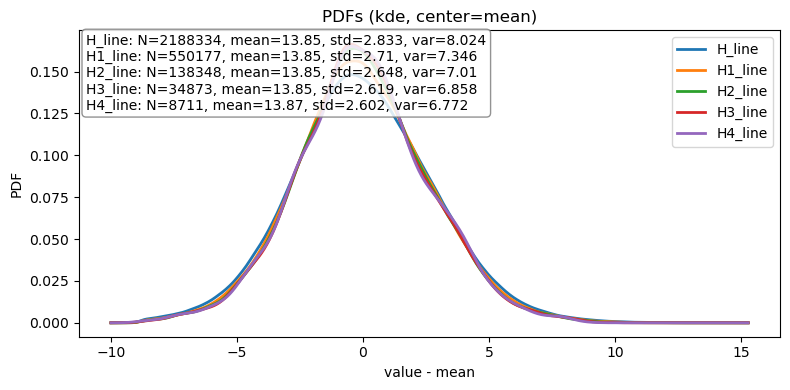

In [7]:
import matrix_plots 

arrays = {"H_line": H_["vv"][H_mask],
          "H1_line": H1_["vv"][H1_mask], 
          "H2_line": H2_["vv"][H2_mask], 
          "H3_line": H3_["vv"][H3_mask],
         "H4_line": H4_["vv"][H4_mask],
         }
fig, ax = matrix_plots.plot_pdfs(arrays, center="mean", method="kde", bw_scale=1.0)
plt.savefig('Imgs/H_pdfs.jpg', bbox_inches='tight')

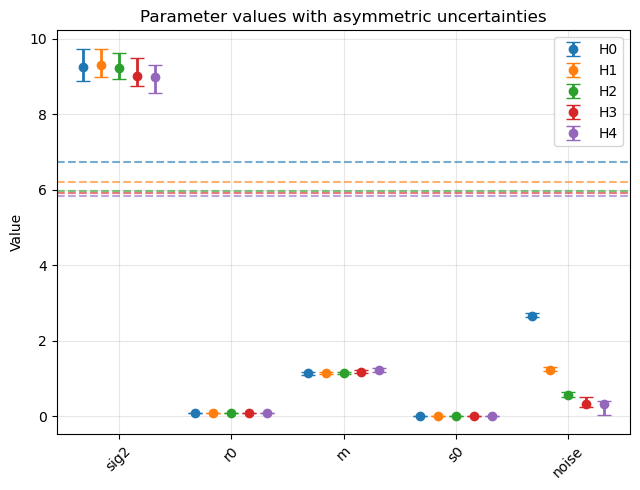

In [8]:

plot_fit_params.plot_param_comp_obs(H_line, H1_line, H2_line, H3_line, H4_line, labels=labels, obs=obs)

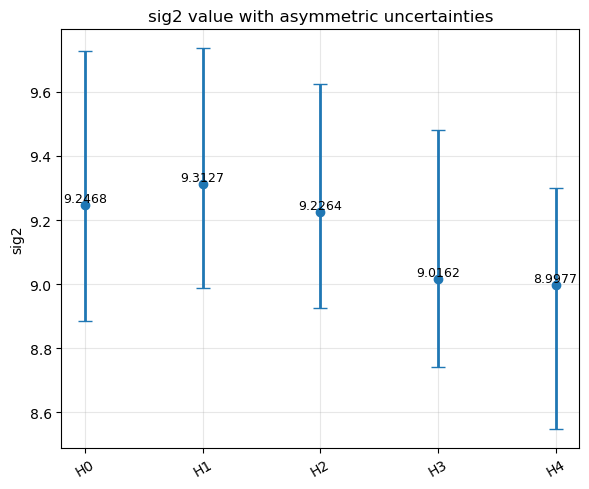

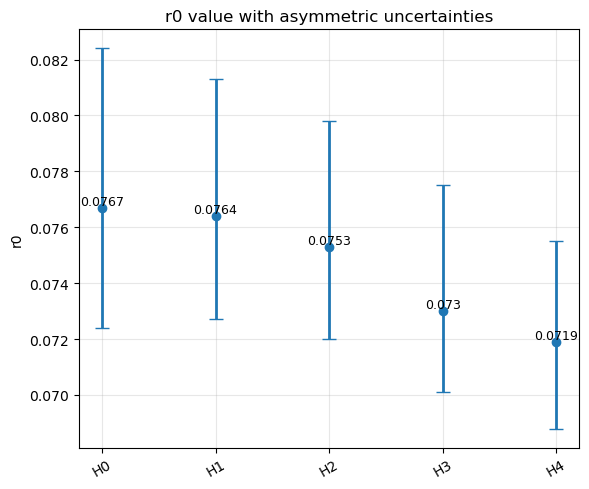

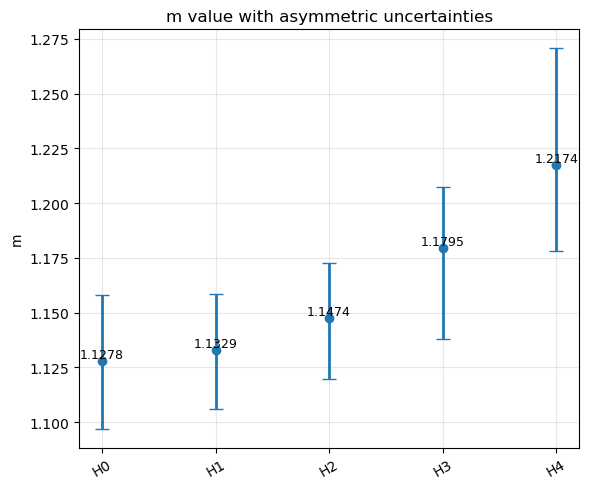

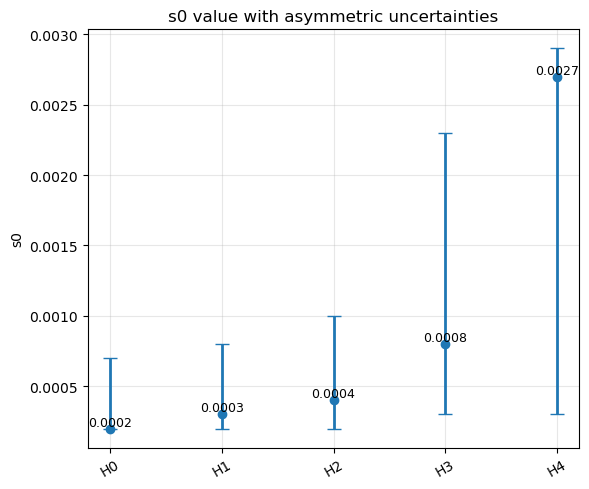

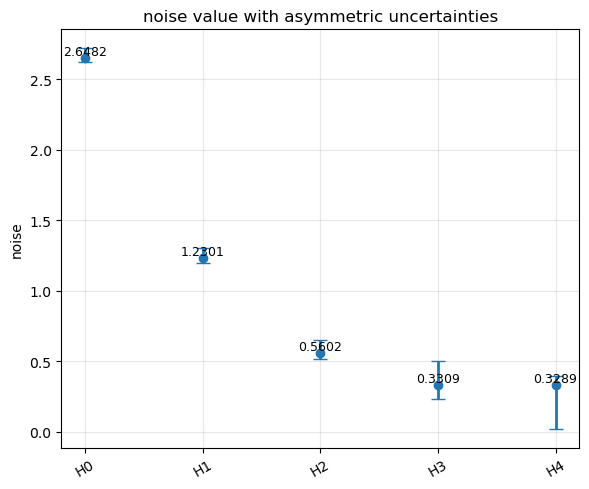

In [9]:
plot_fit_params.plot_param(H_line, H1_line, H2_line, H3_line, H4_line, labels=labels,
                                decimals=4)


# Br plots comparison

In [10]:
raw_bundles = {
    'Bin 0': H_,
    'Bin 1': H1_,
    'Bin 2': H2_,    
    'Bin 3': H3_, 
    'Bin 4': H4_,
}

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def bundle_to_plot_data(bundle, fit_row=0, use_weighted=False):
    """
    Convierte un bundle tipo H_ a un diccionario estándar para plotting.

    Parámetros
    ----------
    bundle : dict
        Diccionario con llaves como 'Br', 'fit', 'meta'
    fit_row : int
        Qué fila de bundle['fit'] usar
    use_weighted : bool
        Si True usa 'Weighted B(r)', si False usa 'Unweighted B(r)'
    """
    Br = bundle['Br']
    fit = bundle['fit']
    meta = bundle['meta']

    bcol = 'Weighted B(r)' if use_weighted else 'Unweighted B(r)'

    mask = np.array(Br['N pairs']) > 0

    r = (10 ** np.array(Br['log10 r'])[mask]) * meta['PIX'] * meta['PC']
    B = np.array(Br[bcol])[mask]

    d = {
        'r': r,
        'B': B,
        'sig': meta.get('SIG', None),
        'sig2_meta': meta.get('SIG2', None),   # valor proveniente de meta
        's0_meta': meta.get('S0', None),       # valor proveniente de meta
        'pc': meta.get('PC', None),
        'pix': meta.get('PIX', None),
        'line': meta.get('LINE', None),
        'binsize': meta.get('BINSIZE', None),

        # parámetros del ajuste
        'sig2': fit.iloc[fit_row]['sig2'] if 'sig2' in fit.columns else None,
        'r0':   fit.iloc[fit_row]['r0']   if 'r0'   in fit.columns else None,
        'm':    fit.iloc[fit_row]['m']    if 'm'    in fit.columns else None,
        's0':   fit.iloc[fit_row]['s0']   if 's0'   in fit.columns else None,
        'noise':fit.iloc[fit_row]['noise']if 'noise'in fit.columns else None,
    }

    return d

In [12]:
data = {
    name: bundle_to_plot_data(bundle, fit_row=0, use_weighted=False)
    for name, bundle in raw_bundles.items()
}

data_in = list(data.keys())

In [13]:
colors = plt.cm.viridis(np.linspace(0, 1, len(data_in)))
markers = ['o', 'o', 'o', 'o', 'o', '+', '+', '+', 's', 's', 's', 's', '.', '.', '.', '.']

annot_x = 0.0001
log_y_positions = np.logspace(1.5, 1.0, len(data_in))
annotation_coords = {
    name: (annot_x, y)
    for name, y in zip(data_in, log_y_positions)
}

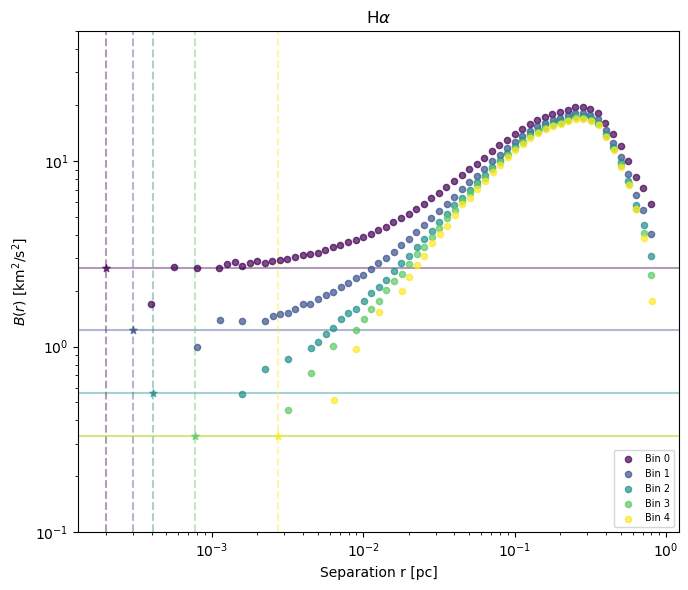

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]

    if d['noise'] is not None:
        ax.axhline(d['noise'], ls='-', color=color, alpha=0.4)

    if d['s0'] is not None:
        ax.axvline(d['s0'], ls='--', color=color, alpha=0.4)

    if d['s0'] is not None and d['noise'] is not None:
        ax.scatter(
            d['s0'], d['noise'],
            color=color, zorder=10, alpha=0.7, s=30, marker='*'
        )

    ax.scatter(
        d['r'], d['B'],
        label=name, color=color, zorder=10, alpha=0.7, s=20
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title(data[data_in[0]]['line'] if data_in else 'Line')
ax.legend(loc='lower right', fontsize=7)
ax.set_ylim(0.1, 50)
plt.tight_layout()
plt.show()

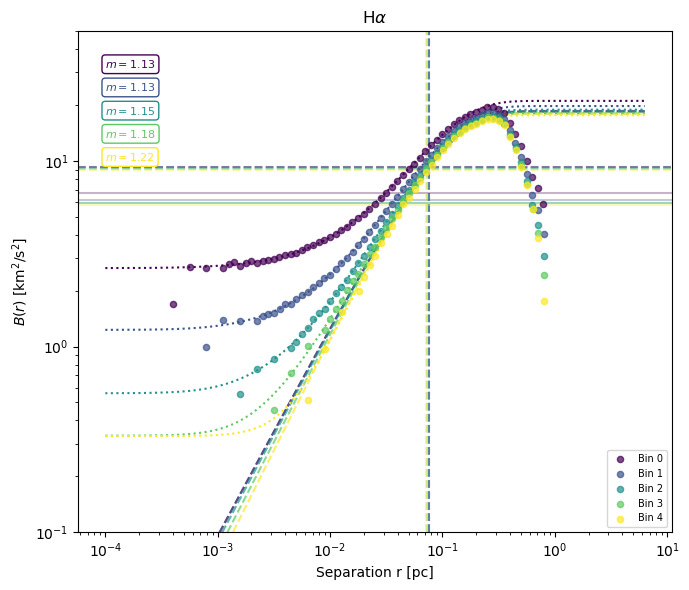

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
rgrid = np.logspace(-4, 0.8, 300)

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]
    marker = markers[i % len(markers)]

    if d['sig2'] is not None:
        ax.axhline(d['sig2'], ls='--', color=color, alpha=0.4)

    if d['r0'] is not None:
        ax.axvline(d['r0'], ls='--', color=color, alpha=0.4)

    ax.scatter(
        d['r'], d['B'],
        label=name, color=color, zorder=10, alpha=0.7, s=20, marker=marker
    )

    if all(d[k] is not None for k in ['r0', 'sig2', 'm', 's0', 'noise']):
        ax.plot(
            rgrid,
            bfunc.bfunc03s(rgrid, d['r0'], d['sig2'], d['m'], d['s0'], d['noise']),
            color=color, ls=':'
        )

    if all(d[k] is not None for k in ['r0', 'sig2', 'm']):
        ax.plot(
            rgrid,
            bfunc.bfunc00s(rgrid, d['r0'], d['sig2'], d['m']),
            color=color, ls='--', alpha=0.7
        )

    if d['sig2_meta'] is not None:
        ax.axhline(d['sig2_meta'], ls='-', color=color, alpha=0.3)

    if d['m'] is not None:
        x_annot, y_annot = annotation_coords[name]
        ax.text(
            x_annot, y_annot,
            f"$m = {d['m']:.2f}$",
            color=color,
            fontsize=8,
            bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3')
        )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title(data[data_in[0]]['line'] if data_in else 'Line')
ax.legend(loc='lower right', fontsize=7)
ax.set_ylim(0.1, 50)
plt.tight_layout()
plt.savefig('Imgs/Brs_H.jpg', bbox_inches='tight')
plt.savefig('Imgs/Brs_H.pdf', bbox_inches='tight')
plt.show()

# Fit results

In [16]:
def print_fit_summary(results):
    L = results['meta']['BOX_SIZE']
    pc = results['meta']['PC']
    FWHM = 2.35

    sig2, sig2_plus, sig2_minus = results['fit']['sig2']
    m, m_plus, m_minus = results['fit']['m']
    r0, r0_plus, r0_minus = results['fit']['r0']
    s0, s0_plus, s0_minus = results['fit']['s0']
    noise, noise_plus, noise_minus = results['fit']['noise']

    print(f"{sig2:.2f}\\PM{{{sig2_plus:.2f}}}{{{sig2_minus:.2f}}}")
    print(f"{noise:.2f}\\PM{{{noise_plus:.2f}}}{{{noise_minus:.2f}}}")
    print(f"{s0:.4f}\\PM{{{s0_plus:.4f}}}{{{s0_minus:.4f}}}")
    print(f"{r0:.2f}\\PM{{{r0_plus:.2f}}}{{{r0_minus:.2f}}}")
    print(f"{L:.2f}")
    print(f"{m:.2f}\\PM{{{m_plus:.2f}}}{{{m_minus:.2f}}}")
    print(f"{L/r0:.2f}")
    print(f"{s0/r0:.4f}")
    print(f"{s0/pc * FWHM:.4f}\\PM{{{s0_plus/pc * FWHM:.4f}}}{{{s0_minus/pc * FWHM:.4f}}}")

    print(f"noise = {(noise + noise_plus):.4f} (km/s)^2")
    print(f"s0(rms) = {(s0 + s0_plus):.4f} pc")
    print(f"s0(FWHM) = {((s0 + s0_plus)/pc * FWHM):.4f} arcsec")

In [23]:
def print_fit_summary_row(results):
    L   = results['meta']['BOX_SIZE']
    pc  = results['meta']['PC']   # [pc / arcsec]
    pix = results['meta']['PIX']  # Instrument resolution [arcsec / pix]
    binsize = results['meta']['BINSIZE'] # [pix]
    FWHM = 2.35

    sig2, sig2_plus, sig2_minus = results['fit']['sig2']
    m, m_plus, m_minus = results['fit']['m']
    r0, r0_plus, r0_minus = results['fit']['r0']
    s0, s0_plus, s0_minus = results['fit']['s0']
    noise, noise_plus, noise_minus = results['fit']['noise']

    row = " & ".join([
        f"{sig2:.2f}\\PM{{{sig2_plus:.2f}}}{{{sig2_minus:.2f}}}",
        f"{noise:.2f}\\PM{{{noise_plus:.2f}}}{{{noise_minus:.2f}}}",
        f"{s0:.4f}\\PM{{{s0_plus:.4f}}}{{{s0_minus:.4f}}}",
        f"{r0:.3f}\\PM{{{r0_plus:.3f}}}{{{r0_minus:.3f}}}",
        f"{L:.2f}",
        f"{m:.2f}\\PM{{{m_plus:.2f}}}{{{m_minus:.2f}}}",
        f"{L/r0:.2f}",
        f"{s0/r0:.4f}",
        f"{(pc*pix*2**binsize)/r0:.2f}",
        f"{s0/pc * FWHM:.4f}\\PM{{{s0_plus/pc * FWHM:.4f}}}{{{s0_minus/pc * FWHM:.4f}}}",
    ])

    print(row)
    print(f"noise      = {(noise + noise_plus):.2f} (km/s)^2")
    print(f"s0(rms)    = {(s0 + s0_plus):.4f} pc")
    print(f"s0(FWHM)   = {((s0 + s0_plus)/pc * FWHM):.2f} arcsec")
    print(f"Binsize/r0 = {(pc*pix*2**binsize)/r0:.2f}" )

In [24]:
print_fit_summary_row(H_)

9.25\PM{0.48}{0.36} & 2.65\PM{0.07}{0.03} & 0.0002\PM{0.0005}{-0.0000} & 0.077\PM{0.006}{0.004} & 0.64 & 1.13\PM{0.03}{0.03} & 8.37 & 0.0026 & 0.01 & 0.2350\PM{0.6205}{-0.0067}
noise      = 2.72 (km/s)^2
s0(rms)    = 0.0007 pc
s0(FWHM)   = 0.86 arcsec
Binsize/r0 = 0.01


In [25]:
print_fit_summary_row(H1_)

9.31\PM{0.42}{0.32} & 1.23\PM{0.07}{0.03} & 0.0003\PM{0.0005}{0.0001} & 0.076\PM{0.005}{0.004} & 0.64 & 1.13\PM{0.03}{0.03} & 8.40 & 0.0040 & 0.02 & 0.3585\PM{0.5971}{0.1108}
noise      = 1.30 (km/s)^2
s0(rms)    = 0.0008 pc
s0(FWHM)   = 0.96 arcsec
Binsize/r0 = 0.02


In [26]:
print_fit_summary_row(H2_)

9.23\PM{0.40}{0.30} & 0.56\PM{0.09}{0.05} & 0.0004\PM{0.0006}{0.0002} & 0.075\PM{0.004}{0.003} & 0.64 & 1.15\PM{0.03}{0.03} & 8.52 & 0.0054 & 0.08 & 0.4816\PM{0.7218}{0.2272}
noise      = 0.65 (km/s)^2
s0(rms)    = 0.0010 pc
s0(FWHM)   = 1.20 arcsec
Binsize/r0 = 0.08


In [27]:
print_fit_summary_row(H3_)

9.02\PM{0.46}{0.28} & 0.33\PM{0.17}{0.10} & 0.0008\PM{0.0015}{0.0005} & 0.073\PM{0.004}{0.003} & 0.64 & 1.18\PM{0.03}{0.04} & 8.77 & 0.0107 & 0.35 & 0.9207\PM{1.7942}{0.6354}
noise      = 0.50 (km/s)^2
s0(rms)    = 0.0023 pc
s0(FWHM)   = 2.71 arcsec
Binsize/r0 = 0.35


In [28]:
print_fit_summary_row(H4_)

9.00\PM{0.30}{0.45} & 0.33\PM{0.07}{0.31} & 0.0027\PM{0.0002}{0.0024} & 0.072\PM{0.004}{0.003} & 0.64 & 1.22\PM{0.05}{0.04} & 8.90 & 0.0378 & 1.41 & 3.2116\PM{0.2372}{2.8596}
noise      = 0.40 (km/s)^2
s0(rms)    = 0.0029 pc
s0(FWHM)   = 3.45 arcsec
Binsize/r0 = 1.41
